In [20]:
from google.colab import files
uploaded = files.upload()

Saving housepricedata.csv to housepricedata (1).csv


In [ ]:
import pandas as pd
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
data = pd.read_csv("housepricedata.csv").values
data

array([[ 8450,     7,     5, ...,     0,   548,     1],
       [ 9600,     6,     8, ...,     1,   460,     1],
       [11250,     7,     5, ...,     1,   608,     1],
       ...,
       [ 9042,     7,     9, ...,     2,   252,     1],
       [ 9717,     5,     6, ...,     0,   240,     0],
       [ 9937,     5,     6, ...,     0,   276,     0]])

In [ ]:
X = data[:,0:10]
Y = data[:, 10]

In [ ]:
X_train, X_val_and_test, Y_train, Y_val_and_test = train_test_split(X, Y, test_size=0.3, random_state=24)

X_val, X_test, Y_val, Y_test = train_test_split(X_val_and_test, Y_val_and_test, test_size=0.5, random_state=24)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val=scaler.transform(X_val)

In [ ]:
print(X_train)

[[-0.04147391 -0.80212979  1.25929356 ... -0.34084912 -0.96370692
   0.20080841]
 [-0.34934049  0.63607485 -0.52696323 ... -0.34084912 -0.96370692
   0.74794107]
 [-0.0355383   0.63607485 -0.52696323 ... -0.34084912  0.5609192
   1.15478331]
 ...
 [-0.1525049   0.63607485 -0.52696323 ... -0.34084912 -0.96370692
   0.90693689]
 [-0.32917684 -0.80212979  1.25929356 ... -0.34084912  0.5609192
  -0.8607225 ]
 [-0.22731115 -0.80212979  0.36616517 ...  0.26921708 -0.96370692
  -1.08518718]]


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val=scaler.transform(X_val)

In [ ]:
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [ ]:
hist=model.fit(X_train, Y_train, epochs=100, batch_size=32, validation_data=(X_val, Y_val))


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6057 - loss: 0.6383 - val_accuracy: 0.8174 - val_loss: 0.5212
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8258 - loss: 0.4835 - val_accuracy: 0.8995 - val_loss: 0.3790
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8748 - loss: 0.3687 - val_accuracy: 0.9087 - val_loss: 0.2886
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8914 - loss: 0.3058 - val_accuracy: 0.9224 - val_loss: 0.2405
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8943 - loss: 0.2758 - val_accuracy: 0.9315 - val_loss: 0.2169
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8982 - loss: 0.2608 - val_accuracy: 0.9361 - val_loss: 0.2054
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9031 - loss: 0.2509 - val_accuracy: 0.9361 - val_loss: 0.1960
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9031 - loss: 0.2450 - val_accuracy: 0.9406 - 

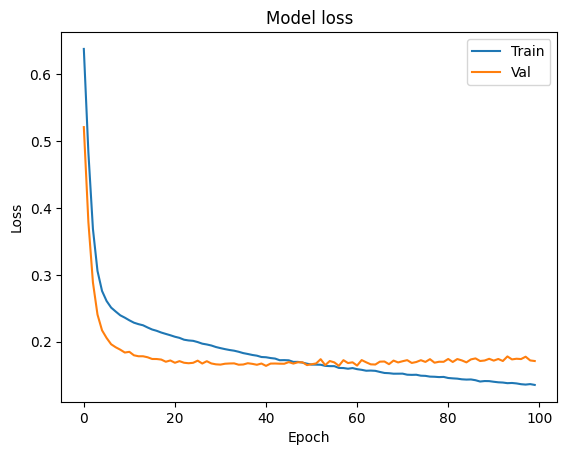

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()


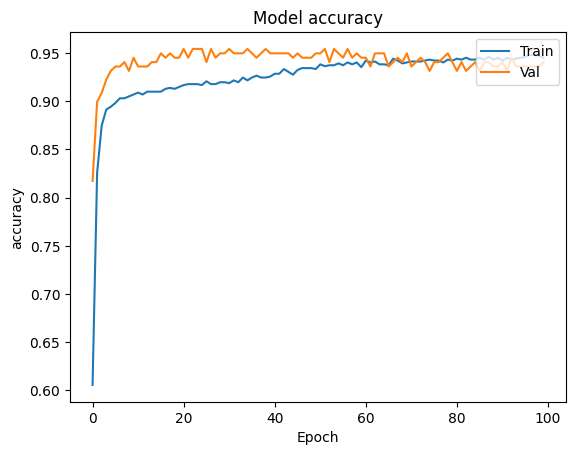

In [ ]:
import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()


In [ ]:
model_2 = Sequential([
    Dense(1000, activation='relu', input_shape=(10,)),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1000, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

hist2 = model_2.fit(X_train, Y_train, epochs=100, batch_size=32, validation_data=(X_val, Y_val))


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.8728 - loss: 0.3221 - val_accuracy: 0.9361 - val_loss: 0.1931
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.8973 - loss: 0.2653 - val_accuracy: 0.9361 - val_loss: 0.1965
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9090 - loss: 0.2240 - val_accuracy: 0.9224 - val_loss: 0.1760
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9217 - loss: 0.1992 - val_accuracy: 0.9361 - val_loss: 0.1735
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9129 - loss: 0.1945 - val_accuracy: 0.9406 - val_loss: 0.1904
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.9178 - loss: 0.1860 - val_accuracy: 0.9178 - val_loss: 0.2035
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9217 - loss: 0.1822 - val_accuracy: 0.8904 - val_loss: 0.2689
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9335 - loss: 0.1664 - val_accuracy: 0.

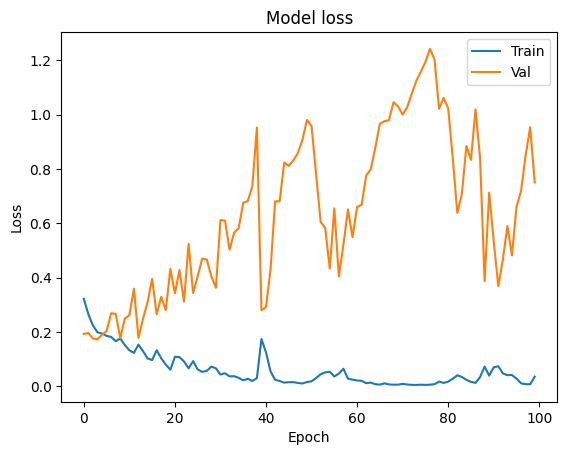

In [ ]:
plt.plot(hist2.history['loss'])
plt.plot(hist2.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

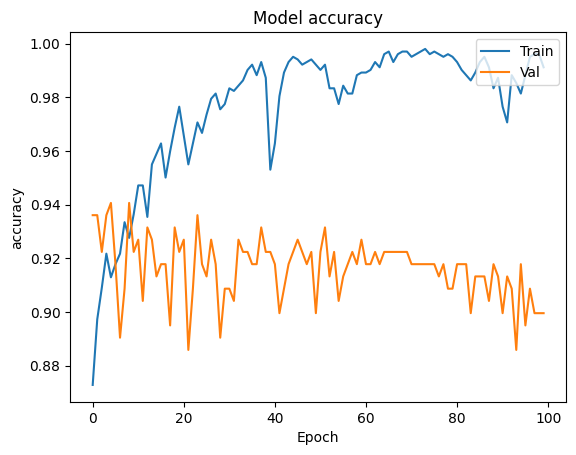

In [ ]:
plt.plot(hist2.history['accuracy'])
plt.plot(hist2.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()


In [17]:
from keras.layers import Dropout
from keras import regularizers

from keras.layers import Dropout
from keras import regularizers

model_3 = Sequential([
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01), input_shape=(10,)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3),
    Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3), Dense(1000, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    Dropout(0.3), Dense(1, activation='sigmoid', kernel_regularizer=regularizers.l2(0.01)), ])


model_3.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])
hist3=model_3.fit(X_train, Y_train, epochs=100, batch_size=32, validation_data=(X_val, Y_val))


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.8542 - loss: 14.6731 - val_accuracy: 0.9406 - val_loss: 4.2904
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.8885 - loss: 1.9116 - val_accuracy: 0.9361 - val_loss: 0.6489
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.8982 - loss: 0.5559 - val_accuracy: 0.9315 - val_loss: 0.4219
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9002 - loss: 0.4576 - val_accuracy: 0.9361 - val_loss: 0.3672
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9002 - loss: 0.4306 - val_accuracy: 0.9315 - val_loss: 0.3554
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - accuracy: 0.9051 - loss: 0.4297 - val_accuracy: 0.9406 - val_loss: 0.3832
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.9012 - loss: 0.3987 - val_accuracy: 0.9269 - val_loss: 0.3410
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.9012 - loss: 0.3868 - val_accuracy

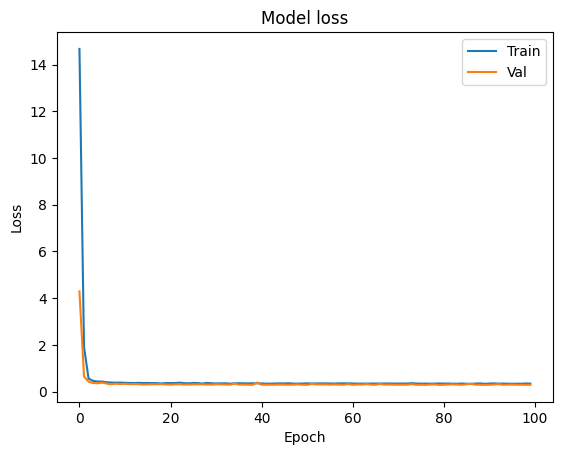

In [18]:
plt.plot(hist3.history['loss'])
plt.plot(hist3.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()

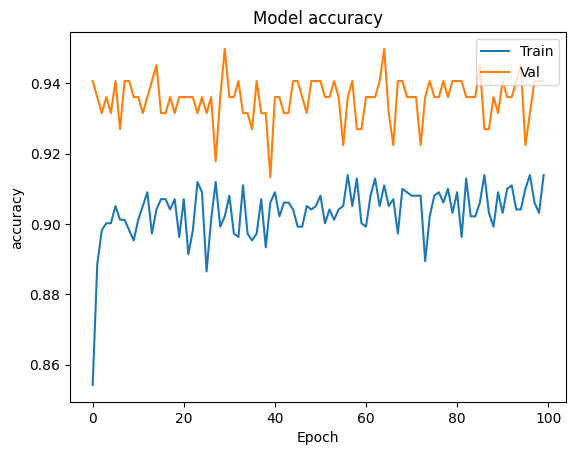

In [19]:
plt.plot(hist3.history['accuracy'])
plt.plot(hist3.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()